---
title: "Homework Module 10 — ODEs with SciPy `odeint`"
---

*Built with Grok Build*

Course: **EEE591 / EEE419 Python for Rapid Engineering Solutions**.

Solve three ordinary differential equation problems with `scipy.integrate.odeint`,
print intermediate values when `debug` is enabled, and plot annotated trajectories.


In [1]:
##########################################################################################
# EEE591_419 Python for Rapid Engineering Solutions - HW_M10: HW_M10.py
# Mark Khusid
##########################################################################################

##########################################################################################
# MW_M10
#                    
##########################################################################################


## Import Libraries


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint


## Create Debug Flag


In [3]:
debug = True
print(f"debug = {debug}")


debug = True


## Create Shared Time Vector


In [4]:
T_START = 0.0
T_END = 7.0
NUM_POINTS = 700

t = np.linspace(T_START, T_END, NUM_POINTS)


In [5]:
if debug:
    print(t[:10])
    print(t[-10:])


[0.         0.01001431 0.02002861 0.03004292 0.04005722 0.05007153
 0.06008584 0.07010014 0.08011445 0.09012876]
[6.90987124 6.91988555 6.92989986 6.93991416 6.94992847 6.95994278
 6.96995708 6.97997139 6.98998569 7.        ]


## Problem 1


### Define Problem 1's Equation Function


In [6]:
def p1_f_prime_y_t(y, t):
    # Return dy/dt for Problem 1
    return np.cos(t)


In [7]:
if debug:
    print(p1_f_prime_y_t(0, t)[:10])


[1.         0.99994986 0.99979943 0.99954875 0.99919782 0.99874668
 0.99819539 0.99754399 0.99679255 0.99594115]


### Define Problem 1's Initial Condition


In [8]:
p1_y_init = 1


### Solve ODE using *odeint*


In [9]:
p1_y_t = odeint(p1_f_prime_y_t, p1_y_init, t)


In [10]:
if debug:
    print(p1_y_t[:10])


[[1.        ]
 [1.01001411]
 [1.02002722]
 [1.03003835]
 [1.04004646]
 [1.05005056]
 [1.06004964]
 [1.0700427 ]
 [1.08002873]
 [1.09000674]]


### Plot Results


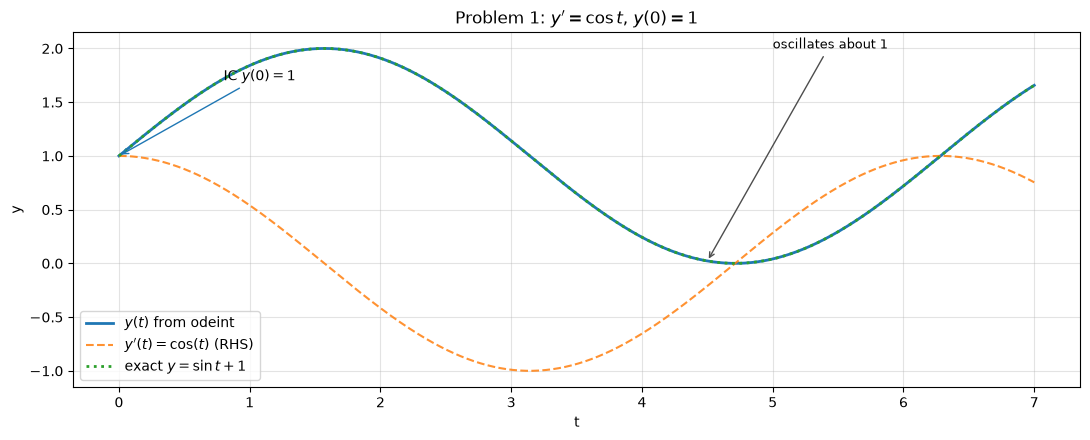

max |y_odeint - y_exact| = 2.853e-07


In [11]:
plt.figure(figsize=(11, 4.5))
plt.plot(t, p1_y_t, label=r"$y(t)$ from odeint", lw=2)
if debug:
    plt.plot(t, p1_f_prime_y_t(0, t), "--", label=r"$y'(t)=\cos(t)$ (RHS)", alpha=0.85)
# Analytic: y = sin(t) + 1
y_exact = np.sin(t) + 1.0
plt.plot(t, y_exact, ":", label=r"exact $y=\sin t+1$", lw=2)
plt.xlabel("t")
plt.ylabel("y")
plt.title(r"Problem 1: $y'=\cos t$, $y(0)=1$")
plt.grid(True, alpha=0.35)
plt.legend(loc="best")
plt.annotate("IC $y(0)=1$", xy=(0, 1), xytext=(0.8, 1.7),
             arrowprops=dict(arrowstyle="->", color="C0"), fontsize=10)
plt.annotate("oscillates about 1", xy=(4.5, float(np.ravel(p1_y_t)[450])), xytext=(5.0, 2.0),
             arrowprops=dict(arrowstyle="->", color="0.3"), fontsize=9)
plt.tight_layout()
plt.show()
if debug:
    err = np.max(np.abs(p1_y_t[:, 0] - y_exact))
    print(f"max |y_odeint - y_exact| = {err:.3e}")


## Problem 2


### Define Problem 2's Equation Function


In [12]:
# y' = -y + t**2 * e**(-2*t) + 10, y(0) = 0
def p2_f_prime_y_t(y, t):
    # Return dy/dt for Problem 2
    return -y + (t**2) * np.exp(-2*t) + 10


In [13]:
if debug:
    print(p2_f_prime_y_t(0, t)[:10])


[10.         10.0000983  10.00038539 10.00084994 10.00148105 10.00226825
 10.00320151 10.0042712  10.00546808 10.00678331]


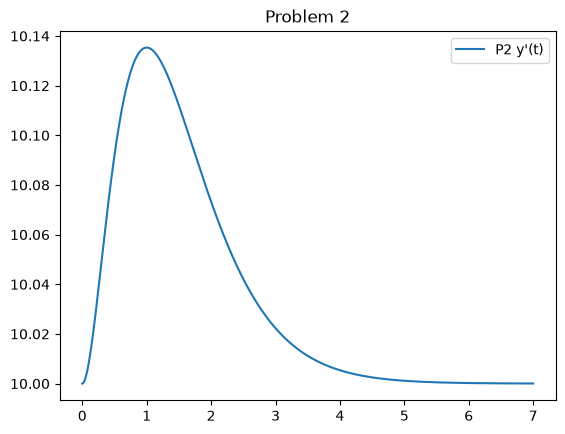

In [14]:
if debug:
    plt.plot(t, p2_f_prime_y_t(0, t), label='P2 y\'(t)')
    plt.title('Problem 2')
    plt.legend()


### Define Problem 2's Initial Condition


In [15]:
p2_y_init = 0


### Solve ODE using *odeint*


In [16]:
p2_y_t = odeint(p2_f_prime_y_t, p2_y_init, t)


In [17]:
if debug:
    print(p2_y_t[:10])


[[0.        ]
 [0.09964362]
 [0.19829629]
 [0.29596971]
 [0.39267536]
 [0.48842448]
 [0.58322809]
 [0.67709705]
 [0.77004196]
 [0.86207326]]


### Plot Results


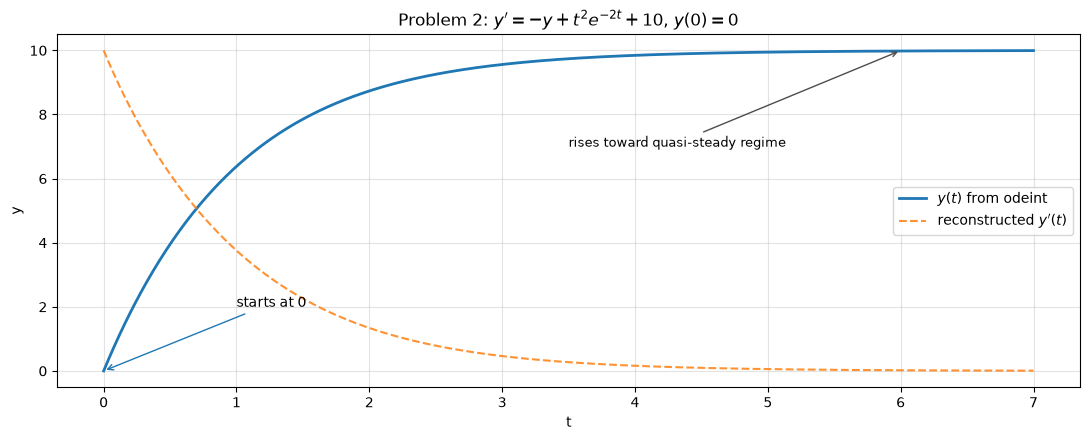

y(T_END) ≈ 9.992651


In [18]:
plt.figure(figsize=(11, 4.5))
plt.plot(t, p2_y_t, label=r"$y(t)$ from odeint", lw=2)
if debug:
    p2_f_prime_y_t_debug = -p2_y_t[:, 0] + (t**2) * np.exp(-2 * t) + 10
    plt.plot(t, p2_f_prime_y_t_debug, "--", label=r"reconstructed $y'(t)$", alpha=0.85)
plt.xlabel("t")
plt.ylabel("y")
plt.title(r"Problem 2: $y'=-y+t^2 e^{-2t}+10$, $y(0)=0$")
plt.grid(True, alpha=0.35)
plt.legend(loc="best")
plt.annotate("starts at 0", xy=(0, 0), xytext=(1.0, 2.0),
             arrowprops=dict(arrowstyle="->", color="C0"), fontsize=10)
# asymptotic trend ~ 10 as steady-ish from forcing
plt.annotate("rises toward quasi-steady regime", xy=(6.0, float(np.ravel(p2_y_t)[-1])),
             xytext=(3.5, float(np.ravel(p2_y_t)[-1]) - 3),
             arrowprops=dict(arrowstyle="->", color="0.3"), fontsize=9)
plt.tight_layout()
plt.show()
if debug:
    print(f"y(T_END) ≈ {float(np.ravel(p2_y_t)[-1]):.6f}")


## Problem 3


### Define Problem 3's Equation Function


In [19]:
# -----------------------------------------------------------------------------
# Problem 3
# y'' + 4y' + 4y = 25cos(t) + 25sin(t)
# y(0) = 1, y'(0) = 1
#
# Convert the second-order ODE into two first-order ODEs.
# Let v = y'. Then:
#       y' = v
#       v' = y'' = 25cos(t) + 25sin(t) - 4v - 4y
# -----------------------------------------------------------------------------
def p3_f_derivatives_y_t(r, t):
    """Return [dy/dt, dv/dt] for Problem 3, where v = y'."""
    y = r[0]
    v = r[1]

    dydt = v
    dvdt = 25*np.cos(t) + 25*np.sin(t) - 4*v - 4*y

    return np.array([dydt, dvdt], float)


### Define Problem 3's Initial Conditions


In [20]:
p3_y_init = np.array([1, 1], dtype=float) # [y(0), y'(0)]


In [21]:
if debug:
    print(p3_y_init)


[1. 1.]


### Solve ODE using *odeint*


In [22]:
p3_f_solutions_y_t = odeint(p3_f_derivatives_y_t, p3_y_init, t)


In [23]:
if debug:
    print(p3_f_solutions_y_t.shape)
    print(p3_f_solutions_y_t[:, 0][:10])
    print(p3_f_solutions_y_t[:, 1][:10])


(700, 2)
[1.         1.0108589  1.02337603 1.03750558 1.05320267 1.07042331
 1.08912438 1.10926361 1.13079957 1.15369165]
[1.         1.16790232 1.33118529 1.48994116 1.64426003 1.79422999
 1.93993714 2.08146564 2.21889776 2.35231391]


In [24]:
p3_y_t = p3_f_solutions_y_t[:, 0]
p3_y_prime_t = p3_f_solutions_y_t[:, 1]


### Plot Results


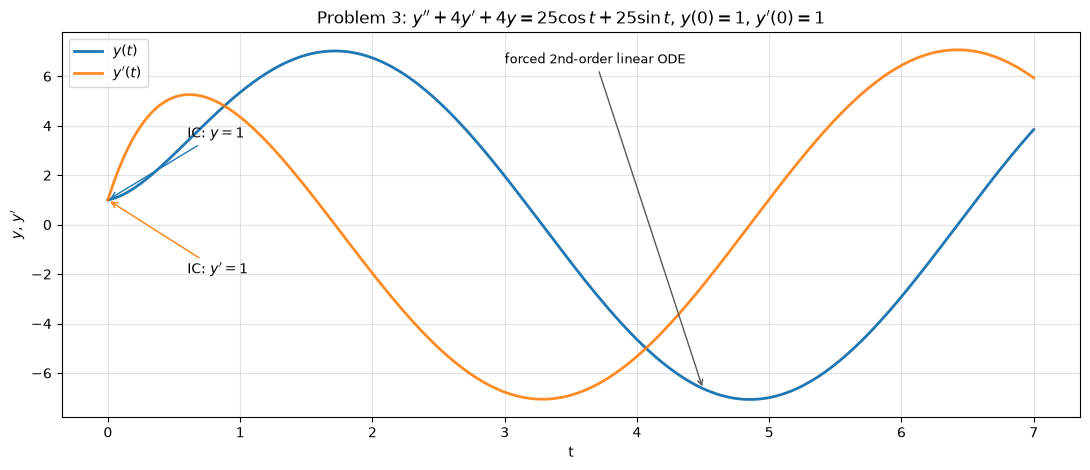

y range: [-7.0715, 7.0247]
y' range: [-7.0610, 7.0711]


In [25]:
plt.figure(figsize=(11, 4.8))
plt.plot(t, p3_y_t, label=r"$y(t)$", lw=2)
plt.plot(t, p3_y_prime_t, label=r"$y'(t)$", lw=2, alpha=0.9)
plt.xlabel("t")
plt.ylabel(r"$y$, $y'$")
plt.title(r"Problem 3: $y''+4y'+4y=25\cos t+25\sin t$, $y(0)=1$, $y'(0)=1$")
plt.grid(True, alpha=0.35)
plt.legend(loc="best")
plt.annotate("IC: $y=1$", xy=(0, 1), xytext=(0.6, 3.5),
             arrowprops=dict(arrowstyle="->", color="C0"), fontsize=10)
plt.annotate("IC: $y'=1$", xy=(0, 1), xytext=(0.6, -2.0),
             arrowprops=dict(arrowstyle="->", color="C1"), fontsize=10)
plt.annotate("forced 2nd-order linear ODE", xy=(4.5, float(np.ravel(p3_y_t)[450])),
             xytext=(3.0, float(np.max(np.ravel(p3_y_t))) - 0.5),
             arrowprops=dict(arrowstyle="->", color="0.35"), fontsize=9)
plt.tight_layout()
plt.show()
if debug:
    print(f"y range: [{p3_y_t.min():.4f}, {p3_y_t.max():.4f}]")
    print(f"y' range: [{p3_y_prime_t.min():.4f}, {p3_y_prime_t.max():.4f}]")


## Summary comparison of all three solutions


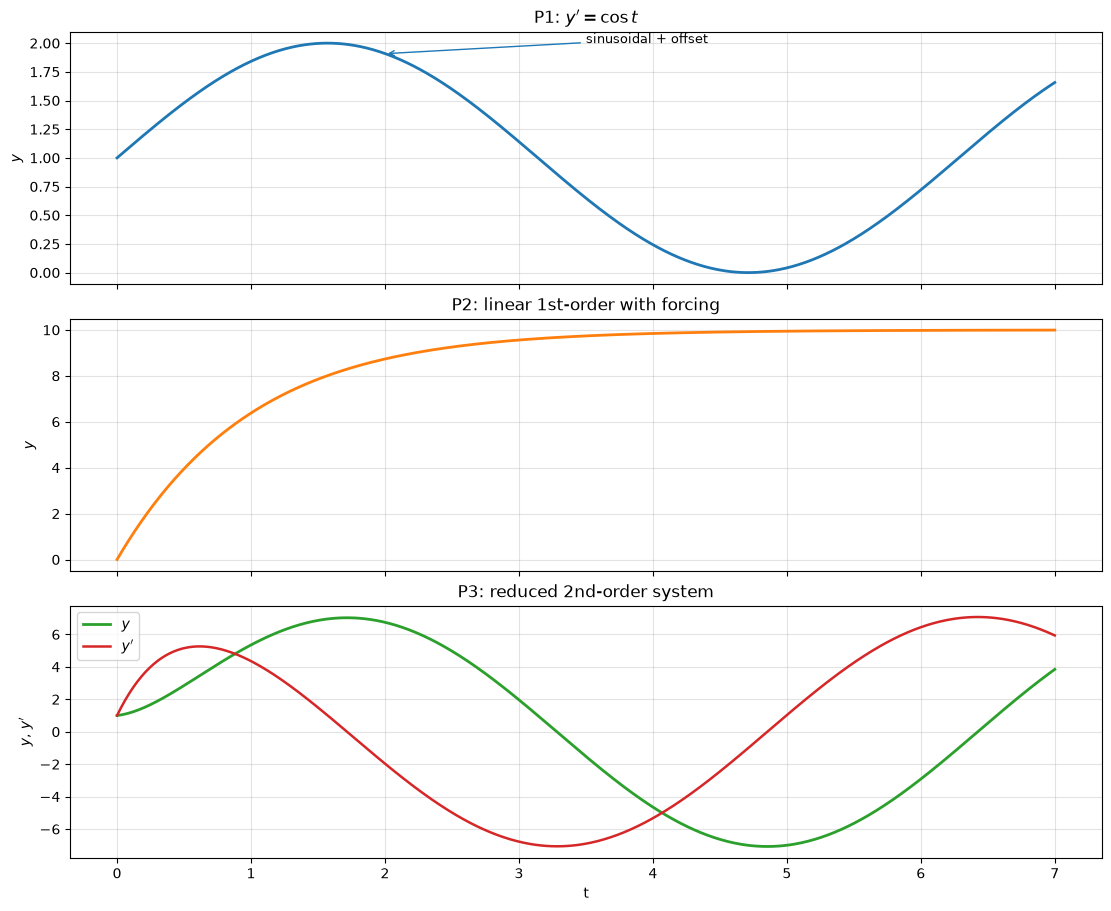

In [26]:
fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, constrained_layout=True)
axes[0].plot(t, p1_y_t, color="C0", lw=2)
axes[0].set_ylabel(r"$y$")
axes[0].set_title(r"P1: $y'=\cos t$")
axes[0].grid(True, alpha=0.35)
axes[0].annotate("sinusoidal + offset", xy=(2, float(np.ravel(p1_y_t)[200])), xytext=(3.5, 2.0),
                 arrowprops=dict(arrowstyle="->", color="C0"), fontsize=9)

axes[1].plot(t, p2_y_t, color="C1", lw=2)
axes[1].set_ylabel(r"$y$")
axes[1].set_title(r"P2: linear 1st-order with forcing")
axes[1].grid(True, alpha=0.35)

axes[2].plot(t, p3_y_t, color="C2", lw=2, label=r"$y$")
axes[2].plot(t, p3_y_prime_t, color="C3", lw=1.8, label=r"$y'$")
axes[2].set_xlabel("t")
axes[2].set_ylabel(r"$y$, $y'$")
axes[2].set_title(r"P3: reduced 2nd-order system")
axes[2].grid(True, alpha=0.35)
axes[2].legend(loc="best")
plt.show()
